In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
import seaborn as sns
import yfinance as yf
import datetime as dt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt
import warnings
warnings.filterwarnings("ignore")

[*********************100%***********************]  1 of 1 completed


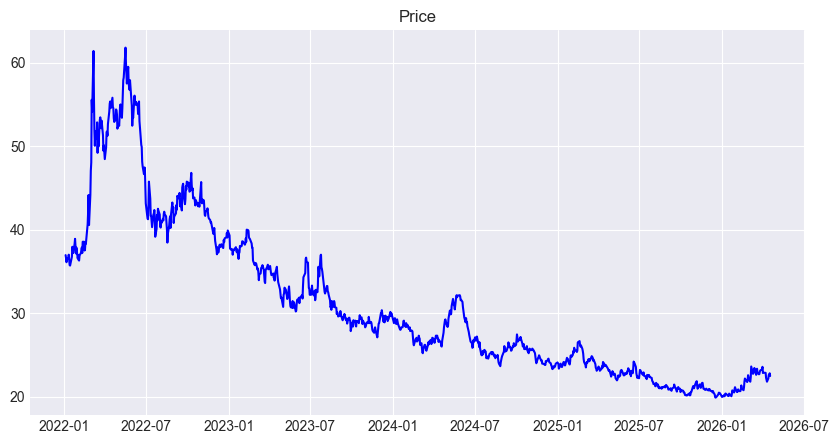

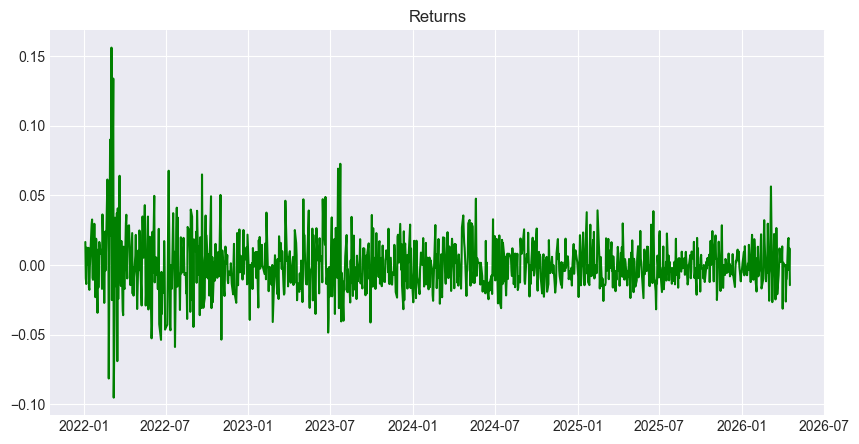

In [154]:
ticker = "WEAT"

data = yf.download(ticker, start="2022-01-01", interval="1d",auto_adjust=False,multi_level_index=False)

data['returns'] = data['Adj Close'].pct_change()

# Drop the missing values
data = data.dropna()

plt.figure(figsize=(10,5))
plt.plot(data['Adj Close'], color='blue')
plt.title("Price")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(data['returns'], color='green')
plt.title("Returns")
plt.show()

In [155]:
window = 50
pred = []
dates = []
coef = []
for i in range(window, len(data)):
    train = data['Adj Close'].iloc[i-window:i]
    model = ARIMA(train, order=(1,0,0)).fit()
    forecast = model.forecast()
    pred.append(forecast.iloc[0])
    dates.append(data.index[i])

pred_series = pd.Series(pred, index=dates)
data['predicted_price'] = pred_series
data['predicted_price'] = data['predicted_price'].shift(1)

# returns
data['returns'] = data['Adj Close'].pct_change()

In [156]:
threshold = 0.001  # 0.1%

change = (data['predicted_price'] - data['predicted_price'].shift(1)) / data['predicted_price'].shift(1)

data['signal'] = np.where(
    change > threshold, 1,
    np.where(change < -threshold, -1, 0)
)
data['strategy_returns'] = data['signal'].shift(1) * data['returns']

In [157]:
final_value = (data['strategy_returns'] + 1).cumprod().iloc[-1]
total_return = (final_value - 1) * 100

print("Total Return:", total_return)

Total Return: -18.148386252335303


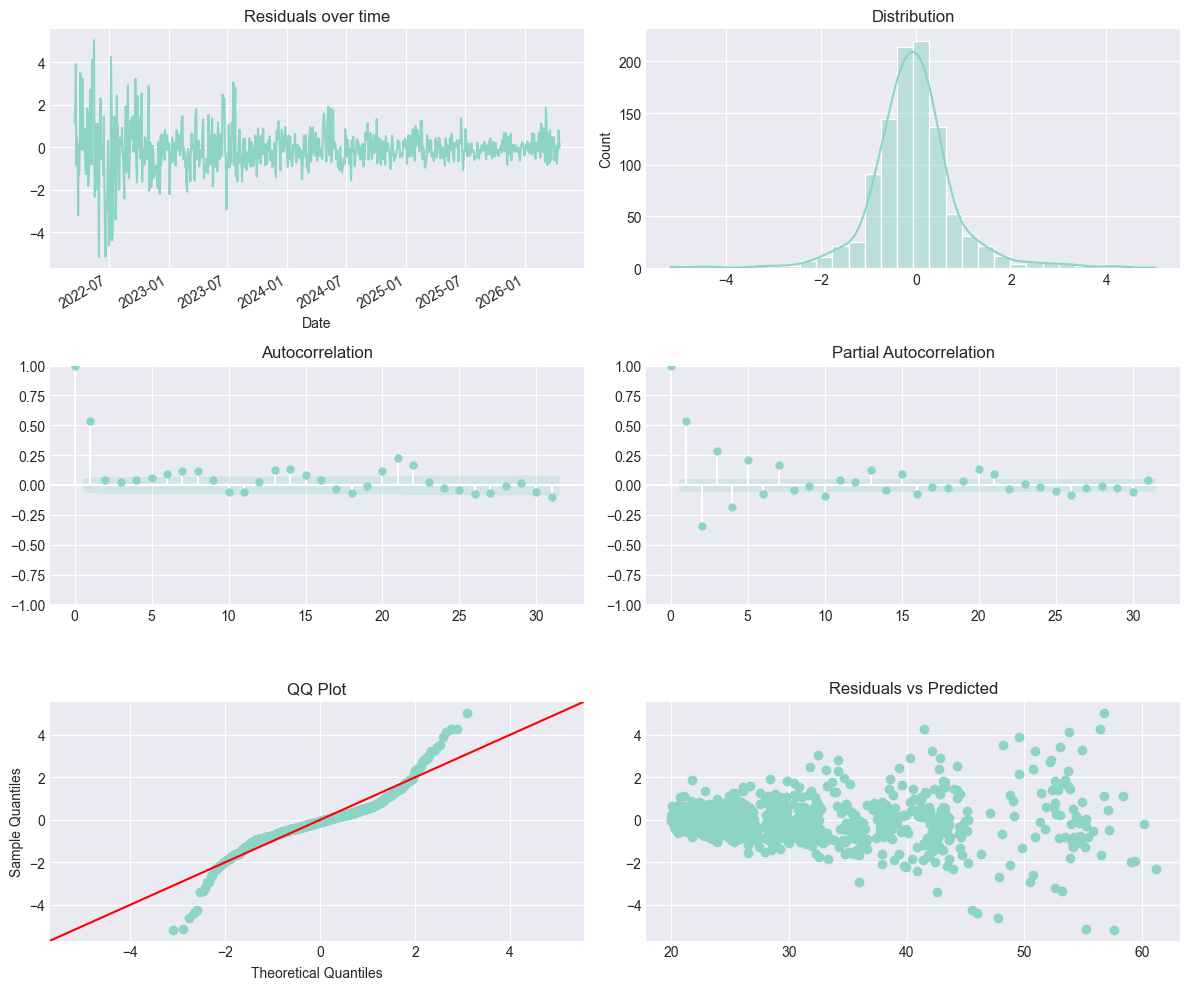

In [158]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

residuals = (data['Adj Close'] - data['predicted_price']).dropna()

fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# 1. Residuals over time
residuals.plot(ax=axes[0,0], title="Residuals over time")

# 2. Histogram
sns.histplot(residuals,ax=axes[0,1], bins=30,kde=True)
axes[0,1].set_title("Distribution")

# 3. ACF
plot_acf(residuals, ax=axes[1,0])

# 4. PACF
plot_pacf(residuals, ax=axes[1,1])

# 5. QQ plot
sm.qqplot(residuals, line='45', ax=axes[2,0])
axes[2,0].set_title("QQ Plot")

# 6. Residual vs Predicted (variance check)
axes[2,1].scatter(data.loc[residuals.index,'predicted_price'], residuals)
axes[2,1].set_title("Residuals vs Predicted")

plt.tight_layout()
plt.show()